In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import networkx as nx 
import graph_tool.all as gt 
import os
import sys
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import assembly_tree as at
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import mcmc
import pandas as pd
import time

In [2]:
protein_path = '../data/proteins/'
circuit_path = '../data/circuits/'
ikea_path = '../data/IkeaData/'
molecule_path = '../data/molecules/'
robot_path = '../data/robots/' 

In [3]:
# target = nx.read_edgelist(protein_path + 'human/edgefiles/CPX-1919.edge', nodetype=int)
# X = np.loadtxt(protein_path + 'human/Xfiles/X_CPX-1919.txt', delimiter=' ')
# target = nx.read_edgelist(circuit_path + 'ltspice_demos/edgefiles/LTM8047_DC1693A.edge', nodetype=int)
# X = np.loadtxt(circuit_path + 'ltspice_demos/Xfiles/X_LTM8047_DC1693A.txt', delimiter=' ')
target = nx.read_edgelist(ikea_path + 'Bench/edgefiles/silveran.edge', nodetype=int)
X = np.loadtxt(ikea_path + 'Bench/Xfiles/X_silveran.txt', delimiter=' ')
if X.ndim == 1:
    X = X.reshape(len(X),1)
capacity = at.extract_deg_cap(target, X).reshape(-1)
O = at.extract_O(target, X)
initial_graph = nx.Graph()
initial_graph.add_nodes_from(np.arange(X.shape[0]))

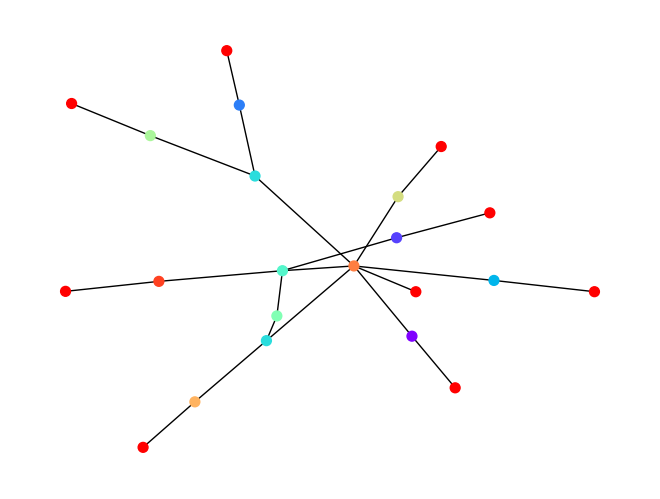

In [4]:
at.draw_network(target, X, node_size=50)

In [5]:
initial_tree = mcmc.AssemblyTree(target, X, O, capacity)

In [6]:
mcmc_obj = mcmc.DesignMCMC(initial_tree)
start = time.time()
mcmc_obj.run_mcmc(10,np.ones(10))
print(f'Time: {time.time() - start:.2f} seconds')

MCMC.py after log prob warning
Time: 2.20 seconds


In [8]:
mcmc_obj.cur_T.known_p

{((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17), ()): [0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0.001],
 ((0, 2, 9), ((0, 2),)): [1.0],
 ((0, 1, 2, 9), ((0, 2), (2, 9))): [0.47],
 ((6, 14, 17), ((17, 14),)): [1.0],
 ((0, 1, 2, 4, 7, 9, 15, 16), ((0, 1), (0, 2), (2, 1), (2, 9), (7, 16))): [0],
 ((5, 6, 14, 17), ((14, 6), (17, 6), (17, 14))): [1.0],
 ((3, 10, 13), ()): [1.0]}

In [14]:
start = time.time()
simulate_p = at.prob_dist(X, O, capacity,
                               max_iters=100, initial_graph = initial_graph,
                               multiedge=False, verbose =False,max_edges = True,
                               rewire_est=False)
simulate_time = time.time() - start

KeyboardInterrupt: 

In [17]:
sol, edges = at.find_optimal_edge_count(X, O, capacity, initial_graph=initial_graph, ret_edges=True, solution=True)

In [19]:
len(edges), target.number_of_edges()

(38, 38)

In [35]:
start = time.time()
sample_p = at.prob_dist(X, O, capacity,
                               max_iters=1000, initial_graph = initial_graph,
                               multiedge=False, verbose =False,max_edges = True,
                               rewire_est=True, sample=True)
sample_time = time.time() - start

In [20]:
start = time.time()
rewire_p = at.prob_dist(X, O, capacity,
                               max_iters=1000, initial_graph = initial_graph,
                               multiedge=False, verbose =False,max_edges = True,
                               rewire_est=True, sample=False)
rewire_time = time.time() - start

In [6]:
start = time.time()
milp_time = at.milp_rewire(X, O, capacity, initial_graph)
milp_time = time.time() - start

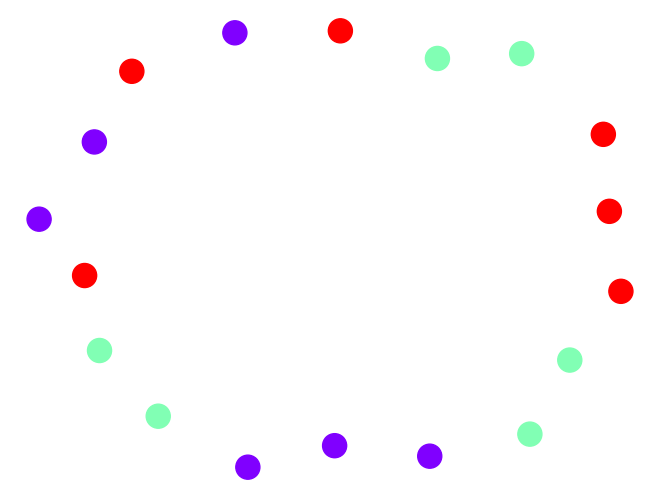

In [12]:
at.draw_network(initial_graph, X)